# Triângulos Retângulos

**Módulo:** 05 – Trigonometria (9º notebook do módulo)

**Pré-requisitos:** [`04_geometria_plana/`](../04_geometria_plana/) (Teorema de Pitágoras, semelhança de triângulos), [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb) (definição de seno, cosseno e tangente via ciclo trigonométrico, para conectar com a definição via triângulo) e [`0505a_arcos_notaveis.ipynb`](0505a_arcos_notaveis.ipynb) (valores exatos de 30°, 45° e 60°, muito usados neste notebook)

**Objetivos de aprendizagem:**
- Revisar e aplicar o Teorema de Pitágoras, incluindo seu uso prático na verificação de ângulos retos.
- Identificar os elementos principais e as relações métricas de um triângulo retângulo.
- Calcular seno, cosseno e tangente de um ângulo agudo a partir dos lados de um triângulo retângulo, relacionando essa definição com a do ciclo trigonométrico.
- Resolver triângulos retângulos completos a partir de poucos dados conhecidos, incluindo problemas de ângulo de elevação e depressão.

**Tempo estimado:** 85 a 105 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/05_trigonometria/0509a_triangulos_retangulos.ipynb)

Você está numa rua e quer saber a altura de um prédio, sem subir nele. Você mede a distância até a base do prédio e o ângulo que sua linha de visão faz com o topo dele. Será que dá para calcular a altura só com esses dois números?

Esse problema é resolvido por completo no Bloco 5 — e a resposta é sim, usando um único conceito: a tangente de um ângulo.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)

## 1. Revisão do Teorema de Pitágoras

O **Teorema de Pitágoras** relaciona os três lados de um triângulo retângulo:

**a² = b² + c²**

onde **a** é a **hipotenusa** (o lado oposto ao ângulo reto, sempre o maior dos três lados) e **b**, **c** são os **catetos** (os outros dois lados). Essa relação vale **exclusivamente** para triângulos retângulos — não existe uma fórmula tão simples para relacionar os lados de um triângulo qualquer (isso só vai aparecer bem mais à frente, com a Lei dos Cossenos).

In [2]:
def eh_triangulo_retangulo(lado_a: float, lado_b: float, lado_c: float, tolerancia: float = 1e-9) -> bool:
    """Verifica se três lados formam um triângulo retângulo, testando a relação de Pitágoras
    com o maior dos três lados no papel de hipotenusa."""
    menor1, menor2, maior = sorted([lado_a, lado_b, lado_c])
    return abs(maior ** 2 - (menor1 ** 2 + menor2 ** 2)) < tolerancia


print("3-4-5:  ", eh_triangulo_retangulo(3, 4, 5))
print("6-8-10: ", eh_triangulo_retangulo(6, 8, 10))
print("4-5-7:  ", eh_triangulo_retangulo(4, 5, 7))

3-4-5:   True
6-8-10:  True
4-5-7:   False


🎯 **Aplicação prática — a regra do 3-4-5:** pedreiros e carpinteiros usam esse teorema há séculos para conferir ângulos retos sem esquadro nem instrumentos sofisticados. Basta marcar 3 unidades de comprimento num lado, 4 unidades no outro lado (que devem formar o ângulo suspeito) e conferir se a distância entre as pontas é exatamente 5 unidades — se for, o ângulo é reto, porque 3² + 4² = 5². Qualquer múltiplo de 3-4-5 funciona igualmente bem (6-8-10, 9-12-15, ...), então a regra se adapta a qualquer escala de obra, do alicerce de uma casa a uma parede de tijolos.

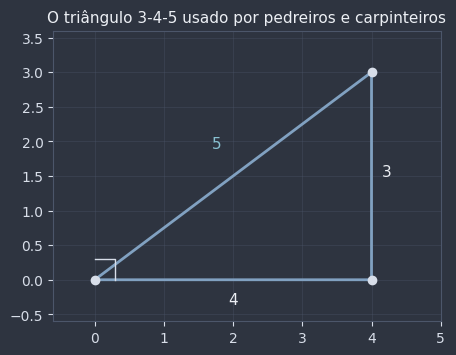

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

vertices_x = [0, 4, 4, 0]
vertices_y = [0, 0, 3, 0]
ax.plot(vertices_x, vertices_y, color=COR_SECUNDARIA, linewidth=2)
ax.plot([0, 0.3, 0.3], [0.3, 0.3, 0], color=NORD_TEXTO_SEC, linewidth=1)

for ponto in [(0, 0), (4, 0), (4, 3)]:
    ax.plot(*ponto, "o", color=NORD_TEXTO_SEC)

ax.annotate("4", xy=(2, -0.35), color=NORD_TEXTO, fontsize=11, ha="center")
ax.annotate("3", xy=(4.15, 1.5), color=NORD_TEXTO, fontsize=11)
ax.annotate("5", xy=(1.7, 1.9), color=COR_PONTO, fontsize=11)

ax.set_xlim(-0.6, 5)
ax.set_ylim(-0.6, 3.6)
ax.set_aspect("equal")
ax.set_title("O triângulo 3-4-5 usado por pedreiros e carpinteiros", color=NORD_TEXTO, fontsize=11)
plt.show()

📎 **Conexão:** o Teorema de Pitágoras foi apresentado pela primeira vez em [`04_geometria_plana/`](../04_geometria_plana/) — aqui ele reaparece como ferramenta de trabalho para tudo o que vem a seguir.

**Pergunta de checagem:** por que o triângulo 6-8-10 também forma um ângulo reto, assim como o 3-4-5?

📖 **Leitura complementar:** [Terno pitagórico — Wikipédia](https://pt.wikipedia.org/wiki/Terno_pitag%C3%B3rico)

## 2. Elementos Principais do Triângulo Retângulo

Num triângulo retângulo, o lado oposto ao ângulo reto é a **hipotenusa** — sempre o maior lado. Os outros dois lados são os **catetos**.

Só faz sentido chamar um cateto de "oposto" ou "adjacente" quando escolhemos um dos dois **ângulos agudos** como referência:

- o **cateto oposto** é o lado que não toca no ângulo de referência;
- o **cateto adjacente** é o lado (diferente da hipotenusa) que toca no ângulo de referência.

Se o ângulo de referência mudar para o outro ângulo agudo, oposto e adjacente **trocam de papel** — o triângulo continua o mesmo, só a referência muda.

Além disso, como a soma dos ângulos internos de qualquer triângulo é 180° e um deles já é 90°, os **dois ângulos agudos de um triângulo retângulo são sempre complementares** (somam 90°).

In [ ]:
def desenhar_triangulo_retangulo(
    cateto_oposto: float,
    cateto_adjacente: float,
    *,
    rotulo_oposto: str = "",
    rotulo_adjacente: str = "",
    rotulo_hipotenusa: str = "",
    rotulo_angulo: str = "",
    vertice_angulo: str = "adjacente",
    titulo: str = "",
    ax=None,
) -> None:
    """Desenha um triângulo retângulo com o ângulo reto na origem, o cateto adjacente sobre o
    eixo x e o cateto oposto sobre o eixo y. `vertice_angulo` controla se o rótulo do ângulo
    agudo é colocado junto ao vértice do cateto adjacente ("adjacente") ou do cateto oposto
    ("oposto")."""
    mostrar = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
        fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    origem = (0.0, 0.0)
    pe_adjacente = (cateto_adjacente, 0.0)
    topo_oposto = (0.0, cateto_oposto)

    xs = [origem[0], pe_adjacente[0], topo_oposto[0], origem[0]]
    ys = [origem[1], pe_adjacente[1], topo_oposto[1], origem[1]]
    ax.plot(xs, ys, color=COR_SECUNDARIA, linewidth=2)

    ax.plot(*origem, "o", color=COR_DESTAQUE)
    ax.plot(*pe_adjacente, "o", color=NORD_TEXTO_SEC)
    ax.plot(*topo_oposto, "o", color=NORD_TEXTO_SEC)

    lado_marcador = min(cateto_oposto, cateto_adjacente) * 0.08
    ax.plot(
        [lado_marcador, lado_marcador, 0], [0, lado_marcador, lado_marcador],
        color=NORD_TEXTO_SEC, linewidth=1,
    )

    ax.annotate(
        rotulo_adjacente, xy=(cateto_adjacente / 2, -cateto_oposto * 0.08),
        color=NORD_TEXTO, fontsize=10, ha="center",
    )
    ax.annotate(
        rotulo_oposto, xy=(-cateto_adjacente * 0.10, cateto_oposto / 2),
        color=NORD_TEXTO, fontsize=10, ha="center", rotation=90,
    )
    ax.annotate(
        rotulo_hipotenusa, xy=(cateto_adjacente / 2 + cateto_adjacente * 0.04, cateto_oposto / 2 + cateto_oposto * 0.04),
        color=COR_PONTO, fontsize=10,
    )
    if rotulo_angulo:
        if vertice_angulo == "adjacente":
            xy_angulo = (cateto_adjacente * 0.80, cateto_oposto * 0.12)
        else:
            xy_angulo = (cateto_adjacente * 0.12, cateto_oposto * 0.82)
        ax.annotate(rotulo_angulo, xy=xy_angulo, color=COR_AVISO, fontsize=10)

    ax.set_xlim(-cateto_adjacente * 0.35, cateto_adjacente * 1.25)
    ax.set_ylim(-cateto_oposto * 0.35, cateto_oposto * 1.25)
    ax.set_aspect("equal")
    if titulo:
        ax.set_title(titulo, color=NORD_TEXTO, fontsize=11)
    if mostrar:
        plt.show()


CATETO_OP_FIXO = 3.0
CATETO_ADJ_FIXO = 4.0
HIPOTENUSA_FIXA = math.hypot(CATETO_OP_FIXO, CATETO_ADJ_FIXO)
ANGULO_ALFA_GRAUS = math.degrees(math.atan2(CATETO_OP_FIXO, CATETO_ADJ_FIXO))
ANGULO_BETA_GRAUS = 90 - ANGULO_ALFA_GRAUS


def widget_elementos_triangulo(referencia: str) -> None:
    """Redesenha o MESMO triângulo (3-4-5), apenas trocando qual ângulo agudo é a referência
    e, com isso, quais catetos são chamados de oposto e adjacente."""
    if referencia == "α (inferior direito)":
        desenhar_triangulo_retangulo(
            CATETO_OP_FIXO, CATETO_ADJ_FIXO,
            rotulo_oposto="cateto oposto a α", rotulo_adjacente="cateto adjacente a α",
            rotulo_hipotenusa=f"hipotenusa = {HIPOTENUSA_FIXA:.2f}",
            rotulo_angulo=f"α = {ANGULO_ALFA_GRAUS:.1f}°", vertice_angulo="adjacente",
            titulo="Elementos em relação a α",
        )
    else:
        desenhar_triangulo_retangulo(
            CATETO_OP_FIXO, CATETO_ADJ_FIXO,
            rotulo_oposto="cateto adjacente a β", rotulo_adjacente="cateto oposto a β",
            rotulo_hipotenusa=f"hipotenusa = {HIPOTENUSA_FIXA:.2f}",
            rotulo_angulo=f"β = {ANGULO_BETA_GRAUS:.1f}°", vertice_angulo="oposto",
            titulo="Elementos em relação a β",
        )
    print(f"α = {ANGULO_ALFA_GRAUS:.1f}°   |   β = {ANGULO_BETA_GRAUS:.1f}°   |   α + β = {ANGULO_ALFA_GRAUS + ANGULO_BETA_GRAUS:.0f}°")


widgets.interact(
    widget_elementos_triangulo,
    referencia=widgets.Dropdown(
        options=["α (inferior direito)", "β (superior esquerdo)"],
        description="referência",
    ),
)

interactive(children=(Dropdown(description='referência', options=('α (inferior direito)', 'β (superior esquerd…

<function __main__.widget_elementos_triangulo(referencia: str) -> None>

📌 **Definição formal:**
- **Hipotenusa:** o lado oposto ao ângulo reto; sempre o maior lado do triângulo.
- **Cateto oposto** (a um ângulo agudo θ): o lado que não toca em θ.
- **Cateto adjacente** (a um ângulo agudo θ): o lado, diferente da hipotenusa, que toca em θ.
- Os dois ângulos agudos de um triângulo retângulo são sempre **complementares**.

**Pergunta de checagem:** se um triângulo retângulo tem um ângulo agudo de 35°, quanto vale o outro ângulo agudo?

## 3. Relações Métricas do Triângulo Retângulo

Ao traçar a **altura relativa à hipotenusa** (o segmento que sai do ângulo reto e cai perpendicularmente sobre a hipotenusa), ela divide a hipotenusa **a** em dois pedaços: a **projeção n** (do lado do cateto adjacente **b**) e a **projeção m** (do lado do cateto oposto **c**).

Essas quatro relações, chamadas **relações métricas**, conectam todos esses elementos:

- **b² = a·n**
- **c² = a·m**
- **h² = m·n**
- **b·c = a·h**

onde **h** é a altura relativa à hipotenusa.

In [5]:
cateto_b = 4.0  # cateto adjacente
cateto_c = 3.0  # cateto oposto
hipotenusa_a = math.hypot(cateto_b, cateto_c)

projecao_n = cateto_b ** 2 / hipotenusa_a  # projeção do cateto b sobre a hipotenusa
projecao_m = cateto_c ** 2 / hipotenusa_a  # projeção do cateto c sobre a hipotenusa
altura_h = cateto_b * cateto_c / hipotenusa_a  # de b*c = a*h

print(f"hipotenusa a = {hipotenusa_a:.4f}")
print(f"projeção n (de b) = {projecao_n:.4f}")
print(f"projeção m (de c) = {projecao_m:.4f}")
print(f"altura h = {altura_h:.4f}")

assert abs(cateto_b ** 2 - hipotenusa_a * projecao_n) < 1e-9  # b² = a·n
assert abs(cateto_c ** 2 - hipotenusa_a * projecao_m) < 1e-9  # c² = a·m
assert abs(altura_h ** 2 - projecao_m * projecao_n) < 1e-9    # h² = m·n
assert abs(cateto_b * cateto_c - hipotenusa_a * altura_h) < 1e-9  # bc = ah
print("As quatro relações métricas se confirmam para este triângulo.")

hipotenusa a = 5.0000
projeção n (de b) = 3.2000
projeção m (de c) = 1.8000
altura h = 2.4000
As quatro relações métricas se confirmam para este triângulo.


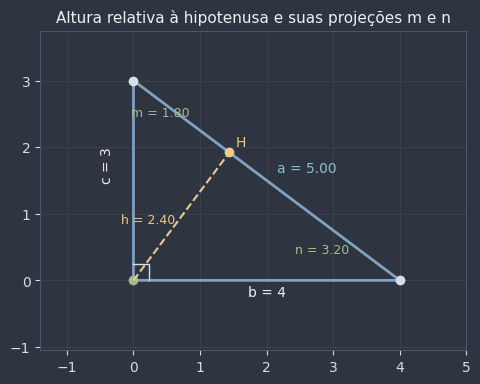

In [6]:
pe_h_x = cateto_b * cateto_c ** 2 / hipotenusa_a ** 2
pe_h_y = cateto_b ** 2 * cateto_c / hipotenusa_a ** 2

fig, ax = plt.subplots(figsize=(5.5, 5))
fig.patch.set_facecolor(NORD_FUNDO)
desenhar_triangulo_retangulo(
    cateto_c, cateto_b,
    rotulo_oposto=f"c = {cateto_c:.0f}", rotulo_adjacente=f"b = {cateto_b:.0f}",
    rotulo_hipotenusa=f"a = {hipotenusa_a:.2f}",
    ax=ax,
)

ax.plot([0, pe_h_x], [0, pe_h_y], color=COR_AVISO, linewidth=1.5, linestyle="--")
ax.plot(pe_h_x, pe_h_y, "o", color=COR_AVISO)
ax.annotate("H", xy=(pe_h_x + 0.1, pe_h_y + 0.1), color=COR_AVISO, fontsize=10)
ax.annotate(f"h = {altura_h:.2f}", xy=(pe_h_x / 2 - 0.9, pe_h_y / 2 - 0.1), color=COR_AVISO, fontsize=9)
ax.annotate(f"n = {projecao_n:.2f}", xy=((cateto_b + pe_h_x) / 2 - 0.3, pe_h_y / 2 - 0.55), color=COR_DESTAQUE, fontsize=9)
ax.annotate(f"m = {projecao_m:.2f}", xy=(pe_h_x / 2 - 0.75, (pe_h_y + cateto_c) / 2), color=COR_DESTAQUE, fontsize=9)
ax.set_title("Altura relativa à hipotenusa e suas projeções m e n", color=NORD_TEXTO, fontsize=11)
plt.show()

💡 **Dica:** você não precisa decorar as quatro relações métricas — todas elas vêm da **semelhança** entre os três triângulos formados ao traçar a altura relativa à hipotenusa (o triângulo grande e os dois pequenos). Sempre que esquecer uma fórmula, dá para rededuzi-la a partir dessa semelhança.

**Pergunta de checagem:** por que os três triângulos formados ao traçar a altura relativa à hipotenusa são semelhantes entre si?

## 4. Razões Trigonométricas no Triângulo Retângulo

Escolhido um ângulo agudo θ de um triângulo retângulo, definimos três razões entre os lados:

- **sen θ = cateto oposto / hipotenusa**
- **cos θ = cateto adjacente / hipotenusa**
- **tg θ = cateto oposto / cateto adjacente**

Essa definição coincide **exatamente** com a do ciclo trigonométrico ([`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb)) quando o ângulo é agudo — a diferença é que aqui os valores vêm diretamente da geometria do triângulo, sem precisar de uma circunferência de raio 1.

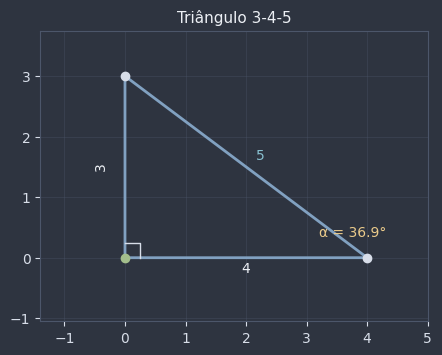

,razão,valor (lados do triângulo),"valor (math, pelo ângulo)"
0,sen(α) = oposto/hipotenusa,0.60,0.60
1,cos(α) = adjacente/hipotenusa,0.80,0.80
2,tg(α) = oposto/adjacente,0.75,0.75


In [7]:
cateto_oposto_ex = 3.0
cateto_adjacente_ex = 4.0
hipotenusa_ex = math.hypot(cateto_oposto_ex, cateto_adjacente_ex)
alfa_graus_ex = math.degrees(math.atan2(cateto_oposto_ex, cateto_adjacente_ex))

sen_alfa = cateto_oposto_ex / hipotenusa_ex
cos_alfa = cateto_adjacente_ex / hipotenusa_ex
tg_alfa = cateto_oposto_ex / cateto_adjacente_ex

desenhar_triangulo_retangulo(
    cateto_oposto_ex, cateto_adjacente_ex,
    rotulo_oposto=f"{cateto_oposto_ex:.0f}", rotulo_adjacente=f"{cateto_adjacente_ex:.0f}",
    rotulo_hipotenusa=f"{hipotenusa_ex:.0f}", rotulo_angulo=f"α = {alfa_graus_ex:.1f}°",
    titulo="Triângulo 3-4-5",
)

tabela_razoes = pd.DataFrame({
    "razão": ["sen(α) = oposto/hipotenusa", "cos(α) = adjacente/hipotenusa", "tg(α) = oposto/adjacente"],
    "valor (lados do triângulo)": [round(sen_alfa, 4), round(cos_alfa, 4), round(tg_alfa, 4)],
    "valor (math, pelo ângulo)": [
        round(math.sin(math.radians(alfa_graus_ex)), 4),
        round(math.cos(math.radians(alfa_graus_ex)), 4),
        round(math.tan(math.radians(alfa_graus_ex)), 4),
    ],
})
tabela_razoes

🕹️ **Widget interativo:** mova o slider do ângulo α e veja, com a hipotenusa mantida fixa, como os catetos mudam e como sen(α), cos(α) e tg(α) são recalculados ao vivo.

In [8]:
def widget_razoes_triangulo(alfa_graus: float, hipotenusa: float) -> None:
    alfa_rad = math.radians(alfa_graus)
    oposto = hipotenusa * math.sin(alfa_rad)
    adjacente = hipotenusa * math.cos(alfa_rad)
    desenhar_triangulo_retangulo(
        oposto, adjacente,
        rotulo_oposto=f"{oposto:.2f}", rotulo_adjacente=f"{adjacente:.2f}",
        rotulo_hipotenusa=f"{hipotenusa:.2f}", rotulo_angulo=f"α = {alfa_graus:.0f}°",
        titulo=(
            f"sen(α)={math.sin(alfa_rad):.3f}  cos(α)={math.cos(alfa_rad):.3f}  "
            f"tg(α)={math.tan(alfa_rad):.3f}"
        ),
    )


widgets.interact(
    widget_razoes_triangulo,
    alfa_graus=widgets.IntSlider(min=5, max=85, step=1, value=40, description="α (°)"),
    hipotenusa=widgets.fixed(5.0),
)

interactive(children=(IntSlider(value=40, description='α (°)', max=85, min=5), Output()), _dom_classes=('widge…

<function __main__.widget_razoes_triangulo(alfa_graus: float, hipotenusa: float) -> None>

📎 **Conexão:** no ciclo trigonométrico ([`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb)), sen(α) e cos(α) são as coordenadas (y, x) do ponto sobre a circunferência de raio 1. Aqui, o mesmo ponto pode ser visto como o vértice de um triângulo retângulo de hipotenusa 1: "razão de lados" e "coordenadas no ciclo" são exatamente a mesma ideia, só que expressas de formas diferentes.

**Pergunta de checagem:** por que a definição de seno pelo triângulo retângulo só funciona para ângulos entre 0° e 90°, enquanto a definição pelo ciclo trigonométrico funciona para qualquer ângulo?

## 5. Ângulos de Elevação e Depressão

Quando um observador olha para um ponto **acima** da linha do horizonte, o ângulo entre a horizontal e a linha de visão é o **ângulo de elevação**. Quando olha para um ponto **abaixo** da horizontal, é o **ângulo de depressão**.

Como as duas linhas horizontais (a do observador e a do ponto observado) são paralelas, e a linha de visão funciona como uma transversal entre elas, os ângulos alternos internos são iguais: o **ângulo de elevação de A para B é sempre igual ao ângulo de depressão de B para A**.

🎯 **Retomando o gancho:** para achar a altura de um prédio sem subir nele, meça a distância até a base e o ângulo de elevação até o topo. O triângulo formado é retângulo (a base do prédio faz 90° com o chão), a distância medida é o cateto adjacente, a altura procurada é o cateto oposto, e:

**tg(ângulo de elevação) = altura / distância**

In [ ]:
def widget_altura_predio(distancia_ate_base: float, angulo_elevacao_graus: float) -> None:
    altura = distancia_ate_base * math.tan(math.radians(angulo_elevacao_graus))
    desenhar_triangulo_retangulo(
        altura, distancia_ate_base,
        rotulo_oposto=f"altura = {altura:.1f} m", rotulo_adjacente=f"{distancia_ate_base:.0f} m",
        rotulo_hipotenusa="linha de visão", rotulo_angulo=f"{angulo_elevacao_graus:.0f}°",
        titulo=f"altura do prédio ≈ {altura:.2f} m",
    )


widgets.interact(
    widget_altura_predio,
    distancia_ate_base=widgets.FloatSlider(min=5, max=80, step=1, value=30, description="distância (m)"),
    angulo_elevacao_graus=widgets.IntSlider(min=5, max=85, step=1, value=35, description="ângulo (°)"),
)

interactive(children=(FloatSlider(value=30.0, description='distância (m)', max=80.0, min=5.0, step=1.0), IntSl…

<function __main__.widget_altura_predio(distancia_ate_base: float, angulo_elevacao_graus: float) -> None>

In [10]:
distancia_predio = 40  # metros
angulo_predio = 50  # graus, ângulo de elevação medido

altura_predio = distancia_predio * math.tan(math.radians(angulo_predio))
print(f"medindo 40 m até a base e um ângulo de elevação de 50°, a altura do prédio é ≈ {altura_predio:.2f} m")

medindo 40 m até a base e um ângulo de elevação de 50°, a altura do prédio é ≈ 47.67 m


🎯 **Aplicação prática — distância inacessível (largura de um rio):** e se o ponto que você quer medir não tiver uma base acessível, como a margem oposta de um rio? Uma solução clássica: escolha dois pontos A e B alinhados com o alvo, separados por uma distância **d** conhecida, e meça o ângulo de elevação em cada um (o ponto mais próximo tem o ângulo maior). Chamando de **x** a distância do ponto mais próximo até a base do alvo e de **h** a altura (ou largura) procurada:

**h = x·tg(ângulo perto) = (x + d)·tg(ângulo longe)**

Duas equações, duas incógnitas — resolvendo o sistema, **h** sai sem que ninguém precise atravessar o rio.

largura do rio ≈ 40.69 m


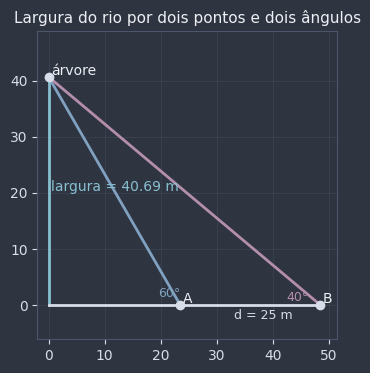

In [11]:
def distancia_por_dois_angulos(
    distancia_entre_pontos: float, angulo_perto_graus: float, angulo_longe_graus: float,
) -> float:
    """Calcula a altura (ou distância perpendicular) de um alvo inacessível a partir de dois
    pontos alinhados com sua base, separados por `distancia_entre_pontos`, e dos ângulos de
    elevação medidos em cada ponto (o ponto mais próximo tem o ângulo maior)."""
    cot_perto = 1 / math.tan(math.radians(angulo_perto_graus))
    cot_longe = 1 / math.tan(math.radians(angulo_longe_graus))
    return distancia_entre_pontos / (cot_longe - cot_perto)


def desenhar_dois_triangulos_distancia(
    distancia_entre_pontos: float, angulo_perto_graus: float, angulo_longe_graus: float,
) -> None:
    """Desenha os dois triângulos retângulos do método de dois pontos e dois ângulos."""
    altura = distancia_por_dois_angulos(distancia_entre_pontos, angulo_perto_graus, angulo_longe_graus)
    x_perto = altura / math.tan(math.radians(angulo_perto_graus))
    x_longe = x_perto + distancia_entre_pontos

    fig, ax = plt.subplots(figsize=(7, 4))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    topo = (0.0, altura)
    ponto_perto = (x_perto, 0.0)
    ponto_longe = (x_longe, 0.0)

    ax.plot([0, 0], [0, altura], color=COR_PONTO, linewidth=2)
    ax.plot([0, x_longe], [0, 0], color=NORD_TEXTO_SEC, linewidth=2)
    ax.plot([topo[0], ponto_perto[0]], [topo[1], ponto_perto[1]], color=COR_SECUNDARIA, linewidth=2)
    ax.plot([topo[0], ponto_longe[0]], [topo[1], ponto_longe[1]], color=COR_EXTRA, linewidth=2)

    for ponto, nome in [(topo, "árvore"), (ponto_perto, "A"), (ponto_longe, "B")]:
        ax.plot(*ponto, "o", color=NORD_TEXTO_SEC)
        ax.annotate(nome, xy=(ponto[0] + 0.4, ponto[1] + 0.4), color=NORD_TEXTO, fontsize=10)

    ax.annotate(f"{angulo_perto_graus:.0f}°", xy=(x_perto - 4, 1.4), color=COR_SECUNDARIA, fontsize=9)
    ax.annotate(f"{angulo_longe_graus:.0f}°", xy=(x_longe - 6, 0.7), color=COR_EXTRA, fontsize=9)
    ax.annotate(
        f"d = {distancia_entre_pontos:.0f} m", xy=((x_perto + x_longe) / 2 - 3, -altura * 0.06),
        color=NORD_TEXTO_SEC, fontsize=9,
    )
    ax.annotate(f"largura = {altura:.2f} m", xy=(0.4, altura / 2), color=COR_PONTO, fontsize=10)

    ax.set_xlim(-2, x_longe + 3)
    ax.set_ylim(-altura * 0.15, altura * 1.2)
    ax.set_aspect("equal")
    ax.set_title("Largura do rio por dois pontos e dois ângulos", color=NORD_TEXTO, fontsize=11)
    plt.show()


largura_rio = distancia_por_dois_angulos(25, 60, 40)
print(f"largura do rio ≈ {largura_rio:.2f} m")
desenhar_dois_triangulos_distancia(25, 60, 40)

📌 **Definição formal:**
- **Ângulo de elevação:** ângulo entre a horizontal do observador e a linha de visão, quando o alvo está **acima** da horizontal.
- **Ângulo de depressão:** ângulo entre a horizontal do observador e a linha de visão, quando o alvo está **abaixo** da horizontal.
- O ângulo de elevação de A para B é sempre igual ao ângulo de depressão de B para A (ângulos alternos internos entre paralelas).

**Pergunta de checagem:** se você está no topo de um prédio olhando para um carro na rua, o ângulo que você mede é de elevação ou de depressão?

📖 **Leitura complementar:** [Triangulação geodésica — Wikipédia](https://pt.wikipedia.org/wiki/Triangula%C3%A7%C3%A3o_geod%C3%A9sica)

## 6. Resolução de Triângulos Retângulos

**Resolver um triângulo** significa encontrar todos os seus lados e ângulos a partir de um subconjunto mínimo de informações. Num triângulo retângulo, o ângulo reto já é conhecido, então basta um dos seguintes pares de dados:

- **dois lados** (usando o Teorema de Pitágoras para o terceiro, e a razão trigonométrica correspondente para os ângulos); ou
- **um lado e um ângulo agudo** (usando sen, cos ou tg para os outros lados, e a complementaridade para o outro ângulo).

In [12]:
def resolver_triangulo_retangulo(
    *,
    cateto_oposto: float | None = None,
    cateto_adjacente: float | None = None,
    hipotenusa: float | None = None,
    angulo_graus: float | None = None,
) -> dict[str, float]:
    """Resolve um triângulo retângulo a partir de exatamente dois dados válidos (dois lados,
    ou um lado e o ângulo agudo de referência), devolvendo hipotenusa, os dois catetos e os
    dois ângulos agudos (θ e seu complementar)."""
    dados = [cateto_oposto, cateto_adjacente, hipotenusa, angulo_graus]
    if sum(dado is not None for dado in dados) != 2:
        raise ValueError("Informe exatamente dois dados: dois lados, ou um lado e um ângulo.")

    if angulo_graus is not None:
        theta = math.radians(angulo_graus)
        if cateto_adjacente is not None:
            cateto_oposto = cateto_adjacente * math.tan(theta)
            hipotenusa = cateto_adjacente / math.cos(theta)
        elif cateto_oposto is not None:
            cateto_adjacente = cateto_oposto / math.tan(theta)
            hipotenusa = cateto_oposto / math.sin(theta)
        else:
            cateto_oposto = hipotenusa * math.sin(theta)
            cateto_adjacente = hipotenusa * math.cos(theta)
    else:
        if hipotenusa is None:
            hipotenusa = math.hypot(cateto_oposto, cateto_adjacente)
        elif cateto_adjacente is None:
            cateto_adjacente = math.sqrt(hipotenusa ** 2 - cateto_oposto ** 2)
        else:
            cateto_oposto = math.sqrt(hipotenusa ** 2 - cateto_adjacente ** 2)
        angulo_graus = math.degrees(math.atan2(cateto_oposto, cateto_adjacente))

    return {
        "cateto_oposto": cateto_oposto,
        "cateto_adjacente": cateto_adjacente,
        "hipotenusa": hipotenusa,
        "angulo_graus": angulo_graus,
        "angulo_complementar_graus": 90 - angulo_graus,
    }


teste_lados = resolver_triangulo_retangulo(cateto_oposto=3, cateto_adjacente=4)
assert abs(teste_lados["hipotenusa"] - 5) < 1e-9
teste_angulo = resolver_triangulo_retangulo(hipotenusa=10, angulo_graus=30)
assert abs(teste_angulo["cateto_oposto"] - 5) < 1e-6
print("Função validada com os dois casos de teste.")

Função validada com os dois casos de teste.


🎯 **Aplicação prática — rampa de acessibilidade:** normas de acessibilidade limitam a inclinação máxima de uma rampa. Dada a altura a vencer e essa inclinação máxima, o comprimento mínimo da rampa é a hipotenusa do triângulo retângulo formado.

In [13]:
inclinacao_maxima_graus = 5.0  # ângulo máximo permitido (valor ilustrativo)
altura_a_vencer = 0.85  # metros

rampa_necessaria = resolver_triangulo_retangulo(cateto_oposto=altura_a_vencer, angulo_graus=inclinacao_maxima_graus)
print(f"comprimento mínimo da rampa: {rampa_necessaria['hipotenusa']:.2f} m")
print(f"espaço horizontal necessário: {rampa_necessaria['cateto_adjacente']:.2f} m")

# e, inversamente: qual é a inclinação de uma rampa já construída?
comprimento_rampa_existente = 9.0  # metros
altura_rampa_existente = 0.75  # metros

rampa_existente = resolver_triangulo_retangulo(cateto_oposto=altura_rampa_existente, hipotenusa=comprimento_rampa_existente)
print(f"inclinação da rampa existente: {rampa_existente['angulo_graus']:.2f}°")
print("dentro do limite!" if rampa_existente["angulo_graus"] <= inclinacao_maxima_graus else "fora do limite!")

comprimento mínimo da rampa: 9.75 m
espaço horizontal necessário: 9.72 m
inclinação da rampa existente: 4.78°
dentro do limite!


⚠️ **Erro comum:** tentar resolver um triângulo retângulo sabendo apenas os dois ângulos agudos, sem nenhum lado. Isso define a **forma** do triângulo, mas não o seu **tamanho** — existem infinitos triângulos semelhantes com os mesmos ângulos, em qualquer escala.

In [14]:
for escala in [1, 2, 5]:
    exemplo = resolver_triangulo_retangulo(cateto_adjacente=escala, angulo_graus=40)
    print(
        f"escala {escala}: adjacente={exemplo['cateto_adjacente']:.2f}  "
        f"oposto={exemplo['cateto_oposto']:.2f}  hipotenusa={exemplo['hipotenusa']:.2f}  "
        "(mesmos ângulos, tamanhos diferentes)"
    )

escala 1: adjacente=1.00  oposto=0.84  hipotenusa=1.31  (mesmos ângulos, tamanhos diferentes)
escala 2: adjacente=2.00  oposto=1.68  hipotenusa=2.61  (mesmos ângulos, tamanhos diferentes)
escala 5: adjacente=5.00  oposto=4.20  hipotenusa=6.53  (mesmos ângulos, tamanhos diferentes)


**Pergunta de checagem:** por que conhecer apenas os dois ângulos agudos de um triângulo retângulo não é suficiente para "resolvê-lo" completamente?

## Resumo — cheat sheet

**Teorema de Pitágoras:** a² = b² + c² (a = hipotenusa, b e c = catetos). Vale só para triângulos retângulos. Um **terno pitagórico** (como 3-4-5) é um trio de inteiros que satisfaz essa relação.

**Elementos:** hipotenusa (lado oposto ao ângulo reto, o maior); cateto oposto e cateto adjacente (definidos em relação a um ângulo agudo escolhido). Os dois ângulos agudos são sempre complementares (somam 90°).

**Relações métricas** (a = hipotenusa, b e c = catetos, h = altura relativa à hipotenusa, m e n = projeções de c e b sobre a hipotenusa):
- b² = a·n
- c² = a·m
- h² = m·n
- b·c = a·h

**Razões trigonométricas** (θ = ângulo agudo de referência):
- sen θ = oposto / hipotenusa
- cos θ = adjacente / hipotenusa
- tg θ = oposto / adjacente

**Ângulo de elevação:** medido para cima a partir da horizontal. **Ângulo de depressão:** medido para baixo. Elevação de A para B = depressão de B para A.

**Para resolver um triângulo retângulo, você precisa de:**
- ✅ dois lados, ou
- ✅ um lado e um ângulo agudo.
- ❌ os dois ângulos agudos sozinhos **não bastam** (fixam a forma, não o tamanho).

## Exercícios

### Básico

In [ ]:
# Exercício Básico 1: um triângulo retângulo tem catetos 5 e 12. Calcule a
# hipotenusa usando o Teorema de Pitágoras (seção 1) e guarde o resultado em
# hipotenusa_ex1.
hipotenusa_ex1 = ...

print(hipotenusa_ex1)

In [ ]:
# Verificação
assert abs(hipotenusa_ex1 - 13) < 1e-6, (
    "Tente de novo, revise: a hipotenusa é math.sqrt(5**2 + 12**2) "
    "(seção 1 - Revisão do Teorema de Pitágoras)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: um triângulo retângulo tem cateto oposto 9, cateto
# adjacente 12 e hipotenusa 15 (em relação ao ângulo alfa). Calcule sen(alfa),
# cos(alfa) e tg(alfa) (seção 4) e guarde em sen_ex2, cos_ex2 e tg_ex2.
sen_ex2 = ...
cos_ex2 = ...
tg_ex2 = ...

print(sen_ex2, cos_ex2, tg_ex2)

In [ ]:
# Verificação
assert abs(sen_ex2 - 9 / 15) < 1e-9, (
    "Tente de novo, revise: sen(alfa) = cateto oposto / hipotenusa "
    "(seção 4 - Razões Trigonométricas no Triângulo Retângulo)."
)
assert abs(cos_ex2 - 12 / 15) < 1e-9, (
    "Tente de novo, revise: cos(alfa) = cateto adjacente / hipotenusa "
    "(seção 4 - Razões Trigonométricas no Triângulo Retângulo)."
)
assert abs(tg_ex2 - 9 / 12) < 1e-9, (
    "Tente de novo, revise: tg(alfa) = cateto oposto / cateto adjacente "
    "(seção 4 - Razões Trigonométricas no Triângulo Retângulo)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: resolva o triângulo retângulo com cateto
# adjacente 10 e ângulo agudo de referência 40°, usando a função
# resolver_triangulo_retangulo (seção 6). Guarde o dicionário retornado em
# resultado_ex3.
resultado_ex3 = ...

print(resultado_ex3)

In [ ]:
# Verificação
esperado_ex3 = resolver_triangulo_retangulo(cateto_adjacente=10, angulo_graus=40)
assert resultado_ex3 == esperado_ex3, (
    "Tente de novo, revise: use resolver_triangulo_retangulo(cateto_adjacente=10, "
    "angulo_graus=40) (seção 6 - Resolução de Triângulos Retângulos)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: um triângulo retângulo tem catetos 6 e 8 (logo,
# hipotenusa 10). Aplique as relações métricas (seção 3) para encontrar a
# altura relativa à hipotenusa e guarde o resultado em altura_ex4.
altura_ex4 = ...

print(altura_ex4)

In [ ]:
# Verificação
esperado_ex4 = (6 * 8) / 10
assert abs(altura_ex4 - esperado_ex4) < 1e-6, (
    "Tente de novo, revise: use b*c = a*h, ou seja, h = (6*8)/10 "
    "(seção 3 - Relações Métricas do Triângulo Retângulo)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: usando dois pontos alinhados com a margem oposta de um
# rio, separados por 40 m, foram medidos os ângulos de elevação de 62° (ponto
# mais próximo) e 35° (ponto mais distante). Calcule a largura do rio com
# distancia_por_dois_angulos (seção 5) e guarde o resultado, arredondado a 2
# casas decimais, em largura_ex5.
largura_ex5 = ...

print(largura_ex5)

In [ ]:
# Verificação
esperado_ex5 = round(distancia_por_dois_angulos(40, 62, 35), 2)
assert largura_ex5 == esperado_ex5, (
    "Tente de novo, revise: use round(distancia_por_dois_angulos(40, 62, 35), 2) "
    "(seção 5 - Ângulos de Elevação e Depressão)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: uma rampa precisa vencer uma altura de 1,0 m, com
# inclinação máxima permitida de 5°, num corredor com 12 m disponíveis na
# horizontal. Calcule o espaço horizontal necessário à inclinação máxima
# (seção 6) e guarde em espaco_necessario_ex6; guarde também em cabe_ex6 (bool)
# se a rampa cabe no espaço disponível.
espaco_necessario_ex6 = ...
cabe_ex6 = ...

print(espaco_necessario_ex6, cabe_ex6)

In [ ]:
# Verificação
esperado_espaco_ex6 = resolver_triangulo_retangulo(cateto_oposto=1.0, angulo_graus=5.0)["cateto_adjacente"]
assert abs(espaco_necessario_ex6 - esperado_espaco_ex6) < 1e-6, (
    "Tente de novo, revise: use resolver_triangulo_retangulo(cateto_oposto=1.0, "
    "angulo_graus=5.0)['cateto_adjacente'] (seção 6 - Resolução de Triângulos Retângulos)."
)
assert cabe_ex6 == (esperado_espaco_ex6 <= 12), (
    "Tente de novo, revise: compare espaco_necessario_ex6 com os 12 m disponíveis "
    "(seção 6 - Resolução de Triângulos Retângulos)."
)
print("Certo!")

## Glossário do bloco

| Termo | Definição |
|---|---|
| Hipotenusa | lado oposto ao ângulo reto num triângulo retângulo; sempre o maior lado |
| Cateto oposto / adjacente | os outros dois lados, nomeados em relação a um ângulo agudo escolhido |
| Terno pitagórico | trio de inteiros (como 3, 4, 5) que satisfaz a relação de Pitágoras |
| Altura relativa à hipotenusa | segmento perpendicular que liga o ângulo reto à hipotenusa |
| Relações métricas | fórmulas que conectam catetos, hipotenusa, altura e suas projeções (b²=an, c²=am, h²=mn, bc=ah) |
| Ângulo de elevação | ângulo entre a horizontal do observador e a linha de visão para um alvo acima dela |
| Ângulo de depressão | ângulo entre a horizontal do observador e a linha de visão para um alvo abaixo dela |
| Resolver um triângulo | encontrar todos os lados e ângulos a partir de um subconjunto mínimo de dados |

## Conexões

**Isso depende de:**
- [`04_geometria_plana/`](../04_geometria_plana/) (Teorema de Pitágoras, semelhança de triângulos)
- [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb) (definição das funções circulares pelo ciclo trigonométrico)
- [`0505a_arcos_notaveis.ipynb`](0505a_arcos_notaveis.ipynb) (valores exatos de 30°, 45° e 60°)

**Isso será usado em:**
- 📌 Triângulos Quaisquer (o triângulo retângulo é o caso particular usado para deduzir tanto a Lei dos Senos quanto a Lei dos Cossenos)
- [`06_geometria_espacial/`](../06_geometria_espacial/) (triângulos retângulos aparecem constantemente em problemas envolvendo sólidos geométricos)
- [`07_geometria_analitica_plana_e_espacial/`](../07_geometria_analitica_plana_e_espacial/) (cálculo de distâncias e ângulos entre pontos se apoia nessas mesmas ideias)